## Módulo 2: Waveform Former y n-Tuple Former

Este notebook implementa la segunda etapa del sistema LoRa: la conversión entre
símbolos numéricos (salida del Módulo 1) y señales chirp.

## Bloques implementados

1. **Up-chirp base** — la señal fundamental del sistema
2. **Down-chirp** — su conjugado, usado en el receptor
3. **Waveform Former** — convierte símbolos en chirps (transmisor)
4. **n-Tuple Former** — recupera símbolos desde chirps (receptor)
5. **Verificación exhaustiva** — todos los símbolos posibles
6. **Visualizaciones** — frecuencia instantánea, espectrograma y FFT post-dechirping


## 1. Librerías e imports del Módulo 1

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Funciones reutilizadas del Módulo 1 ----------

def codificador(bits, SF):
    bits = np.array(bits)
    if len(bits) % SF != 0:
        raise ValueError(f"La cantidad de bits ({len(bits)}) debe ser múltiplo de SF ({SF})")
    num_simbolos = len(bits) // SF
    simbolos = np.zeros(num_simbolos, dtype=int)
    for i in range(num_simbolos):
        bloque = bits[i * SF : (i + 1) * SF]
        valor = 0
        for posicion, bit in enumerate(bloque):
            peso = 2 ** (SF - 1 - posicion)
            valor += bit * peso
        simbolos[i] = valor
    return simbolos

def decodificador(simbolos, SF):
    simbolos = np.array(simbolos, dtype=int)
    bits = np.zeros(len(simbolos) * SF, dtype=int)
    for i, simbolo in enumerate(simbolos):
        valor_restante = int(simbolo)
        for posicion in range(SF):
            peso = 2 ** (SF - 1 - posicion)
            if valor_restante >= peso:
                bits[i * SF + posicion] = 1
                valor_restante -= peso
    return bits

def calcular_ber(bits_tx, bits_rx):
    bits_tx = np.array(bits_tx)
    bits_rx = np.array(bits_rx)
    if len(bits_tx) != len(bits_rx):
        raise ValueError("Los vectores de bits deben tener la misma longitud")
    return np.sum(bits_tx != bits_rx) / len(bits_tx)

print("Módulo 1 cargado correctamente.")

Módulo 1 cargado correctamente.


El Módulo 1 dejaba una lista de símbolos. El trabajo del Módulo 2 es convertir cada uno de esos números en una señal física que se pueda transmitir por el aire, y después recuperar el símbolo original a partir de esa señal en el receptor. La señal que usa LoRa se llama chirp.

Un chirp es una señal cuya frecuencia varía linealmente en el tiempo. En LoRa se usan chirps que suben de frecuencia denominados up-chirps.

## 2. Parámetros del sistema

| Parámetro | Símbolo | Valor |
|-----------|---------|-------|
| Spreading Factor | SF | 7 |
| Símbolos posibles | N | 2^SF = 128 |
| Ancho de banda | BW | 125 kHz |
| Frec. de muestreo | Fs | = BW |
| Duración de símbolo | T | N/BW |
| Muestras por símbolo | M | = N |

**¿Por qué Fs = BW?**  
Con esta elección hay exactamente una muestra digital por cada "bin" de frecuencia posible.
Es la frecuencia de muestreo mínima que permite representar los N símbolos distintos sin ambigüedad.


In [ ]:
SF  = 7
BW  = 125e3       # Ancho de banda: 125 kHz
Fs  = BW          # Frecuencia de muestreo = BW → OSR = 1
N   = 2**SF       # Cantidad de símbolos posibles = cantidad de muestras por chirp
T   = N / BW      # Duración de cada símbolo en segundos

print(f"SF  = {SF}")
print(f"BW  = {BW/1e3:.0f} kHz")
print(f"Fs  = {Fs/1e3:.0f} kHz")
print(f"N   = {N}  (símbolos posibles: 0 a {N-1})")
print(f"T   = {T*1e3:.3f} ms por símbolo")

SF  = 7
BW  = 125 kHz
Fs  = 125 kHz
N   = 128  (símbolos posibles: 0 a 127)
T   = 1.024 ms por símbolo


## 3. Up-chirp base

El up-chirp base es el símbolo 0: un chirp que sube linealmente de −BW/2 a +BW/2 
durante T segundos. Todos los demás símbolos se generan rotando este chirp.

$$x_{base}[k] = e^{j2\pi \left( \frac{k^2}{2N} - \frac{k}{2} \right)}, \quad k = 0, 1, \ldots, N-1$$



In [14]:
def up_chirp_base(SF, BW, Fs):
    """
    Genera el up-chirp base (símbolo 0) del sistema LoRa.

    La frecuencia instantánea sube linealmente de -BW/2 a +BW/2
    a lo largo de N muestras.
    """
    N = 2**SF
    chirp = np.zeros(N, dtype=complex)

    for k in range(N):
        # Argumento de la exponencial compleja:
        # k²/(2N) genera fase cuadrática → frecuencia lineal creciente
        # -k/2    desplaza la frecuencia inicial a -BW/2
        argumento = k**2 / (2*N) - k/2
        chirp[k] = np.exp(1j * 2 * np.pi * argumento)

    return chirp

cb = up_chirp_base(SF, BW, Fs)
print(f"Up-chirp base: {len(cb)} muestras, dtype={cb.dtype}")
print(f"Amplitud de cada muestra: {np.abs(cb[0]):.4f}  (debe ser 1.0)")

Up-chirp base: 128 muestras, dtype=complex128
Amplitud de cada muestra: 1.0000  (debe ser 1.0)


## 4. Down-chirp

El down-chirp es el conjugado complejo del up-chirp base.
Conjugar una señal compleja invierte el signo de su fase por lo que la frecuencia baja en vez de subir.

Se usa en el receptor para cancelar la rampa del chirp recibido 
y convertirlo en un tono puro.


In [15]:
def down_chirp(SF, BW, Fs):
    """Genera el down-chirp: conjugado complejo del up-chirp base."""
    return np.conj(up_chirp_base(SF, BW, Fs))

dc = down_chirp(SF, BW, Fs)
print(f"Down-chirp: {len(dc)} muestras")

Down-chirp: 128 muestras


## 5. Waveform Former

Para codificar el símbolo `s`, se rota cíclicamente el up-chirp base `s` posiciones
hacia la izquierda con `np.roll(chirp_base, -s)`.

¿Por qué rotar a la izquierda?  
Rotar a la izquierda `s` posiciones hace que el chirp arranque en una frecuencia 
mayor, lo que corresponde a un símbolo con valor más alto.
La continuidad cíclica de `np.roll` garantiza que cuando la frecuencia llega a +BW/2 
"salta" a -BW/2 y sigue subiendo, generando el salto visible en el espectrograma.


In [16]:
def waveform_former(simbolos, SF, BW, Fs):
    """
    Convierte una secuencia de símbolos en una matriz de chirps LoRa.

    Para cada símbolo s, rota cíclicamente el up-chirp base s posiciones
    hacia la izquierda (np.roll con desplazamiento negativo).

    Parámetros
    ----------
    simbolos : array-like de enteros (salida del codificador del Módulo 1)
    SF, BW, Fs : parámetros del sistema

    Retorna
    -------
    waveform : np.array complejo de shape (len(simbolos), N)
               cada fila es el chirp correspondiente a un símbolo
    """
    N = 2**SF
    simbolos = np.array(simbolos)
    chirp_base = up_chirp_base(SF, BW, Fs)

    waveform = np.zeros((len(simbolos), N), dtype=complex)

    for i, s in enumerate(simbolos):
        # Rotación cíclica hacia la izquierda: el símbolo s define
        # cuántos "bins" se desplaza el punto de inicio del chirp
        waveform[i] = np.roll(chirp_base, -s)

    return waveform

# Prueba rápida
simbolos_prueba = np.array([0, 32, 64, 96])
wf = waveform_former(simbolos_prueba, SF, BW, Fs)
print(f"Waveform shape: {wf.shape}  (4 símbolos × {N} muestras)")

Waveform shape: (4, 128)  (4 símbolos × 128 muestras)


## 6. n-Tuple Former (receptor)

Para cada fila de la matriz de waveforms:

1. **Dechirping**: multiplica la fila por el down-chirp → convierte el chirp en tono puro.
2. **FFT**: transforma al dominio de la frecuencia.
3. **argmax**: el bin con mayor energía es el símbolo recuperado.

Con OSR=1, el argmax devuelve directamente el símbolo (el bin `s` tiene toda la energía).


In [17]:
def n_tuple_former(waveform, SF, BW, Fs):
    """
    Recupera los símbolos a partir de una matriz de waveforms LoRa.

    Para cada fila (chirp):
      1. Multiplica por el down-chirp (dechirping)
      2. Aplica FFT
      3. Detecta el bin con mayor energía → ese bin es el símbolo

    Parámetros
    ----------
    waveform : np.array complejo de shape (num_simbolos, N)
    SF, BW, Fs : parámetros del sistema

    Retorna
    -------
    simbolos_rx : np.array de enteros con los símbolos detectados
    """
    dc = down_chirp(SF, BW, Fs)
    num_simbolos = waveform.shape[0]
    simbolos_rx = np.zeros(num_simbolos, dtype=int)

    for i in range(num_simbolos):
        # Paso 1: dechirping — multiplicamos cada muestra por el down-chirp
        dechirped = waveform[i] * dc

        # Paso 2: FFT — pasamos al dominio de la frecuencia
        espectro = np.fft.fft(dechirped)

        # Paso 3: el bin con más energía revela el símbolo
        simbolos_rx[i] = np.argmax(np.abs(espectro))

    return simbolos_rx

## 7. Verificación completa: bits → chirps → bits

Probamos el ciclo completo sin ruido. La BER debe ser exactamente 0.


In [18]:
np.random.seed(7)
num_simbolos = 10
bits_tx = np.random.randint(0, 2, num_simbolos * SF)
simbolos_tx = codificador(bits_tx, SF)

# Modulación: símbolos → chirps
wf = waveform_former(simbolos_tx, SF, BW, Fs)

# Demodulación: chirps → símbolos
simbolos_rx = n_tuple_former(wf, SF, BW, Fs)

# Decodificación: símbolos → bits
bits_rx = decodificador(simbolos_rx, SF)

print("Símbolos TX:", simbolos_tx)
print("Símbolos RX:", simbolos_rx)
print("¿Coinciden?", np.array_equal(simbolos_tx, simbolos_rx))
print(f"BER: {calcular_ber(bits_tx, bits_rx):.4f}  (esperado: 0.0000)")

Símbolos TX: [87 85  4 51 19 27  8 61 35 13]
Símbolos RX: [87 85  4 51 19 27  8 61 35 13]
¿Coinciden? True
BER: 0.0000  (esperado: 0.0000)


## 8. Verificación exhaustiva: todos los símbolos posibles

Verificamos que los 128 símbolos posibles (SF=7) modulan y demodulan sin errores.


In [19]:
def verificar_todos_simbolos(SF, BW, Fs):
    N = 2**SF
    errores = 0
    for s in range(N):
        wf = waveform_former([s], SF, BW, Fs)
        s_rec = n_tuple_former(wf, SF, BW, Fs)[0]
        if s_rec != s:
            errores += 1
            print(f"  ❌ Falla: transmití {s}, recuperé {s_rec}")
    if errores == 0:
        print(f"✅ Los {N} símbolos posibles (SF={SF}) se modulan y demodulan correctamente.")
    else:
        print(f"Se encontraron {errores} errores de {N} símbolos.")

verificar_todos_simbolos(SF, BW, Fs)

✅ Los 128 símbolos posibles (SF=7) se modulan y demodulan correctamente.


## 9. Visualización 1: frecuencia instantánea del up-chirp base

La frecuencia instantánea se calcula como la derivada de la fase:

$$f_{inst}[k] \approx \frac{\angle x[k+1] - \angle x[k]}{2\pi} \cdot Fs$$

Para el chirp base debería verse una rampa lineal de −BW/2 a +BW/2.


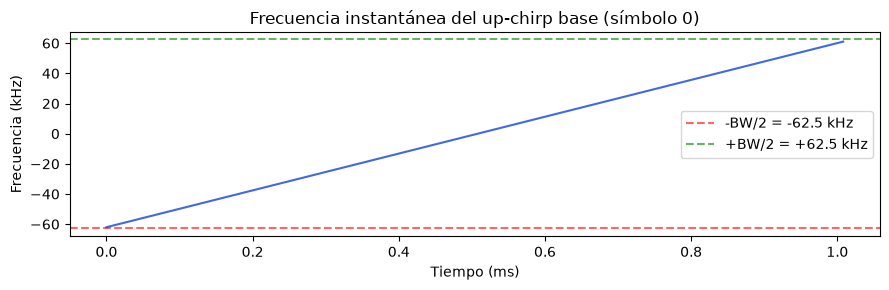

In [20]:
fase = np.unwrap(np.angle(cb))
freq_inst = np.diff(fase) / (2 * np.pi) * Fs
t_ms = np.arange(len(freq_inst)) / Fs * 1e3

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t_ms, freq_inst / 1e3, color='royalblue')
ax.axhline(-BW/2/1e3, color='red',  linestyle='--', alpha=0.6, label='-BW/2 = -62.5 kHz')
ax.axhline( BW/2/1e3, color='green', linestyle='--', alpha=0.6, label='+BW/2 = +62.5 kHz')
ax.set_title("Frecuencia instantánea del up-chirp base (símbolo 0)")
ax.set_xlabel("Tiempo (ms)")
ax.set_ylabel("Frecuencia (kHz)")
ax.legend()
plt.tight_layout()
plt.show()

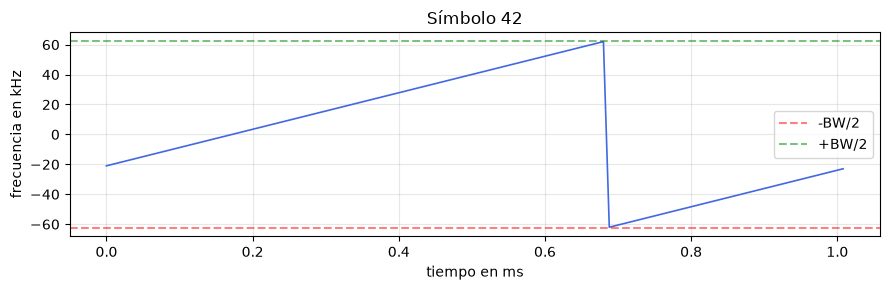

In [34]:
# Símbolo 42 (ejemplo cualquiera) para ver el salto característico de los chirps rotados

chirp_42 = waveform_former([42], SF, BW, Fs)[0]

fase_42 = np.unwrap(np.angle(chirp_42))
freq_inst_42 = np.diff(fase_42) / (2*np.pi) * Fs
t_ms = np.arange(len(freq_inst_42)) / Fs * 1e3

fig, ax = plt.subplots(figsize=(9,3))
ax.plot(t_ms, freq_inst_42 / 1e3, color='royalblue', linewidth=1.2)
ax.set_title("Símbolo 42")
ax.set_xlabel("tiempo en ms")
ax.set_ylabel("frecuencia en kHz")
ax.axhline(-BW/2/1e3, color='red', linestyle='--', alpha=0.5, label='-BW/2')
ax.axhline(BW/2/1e3, color='green', linestyle='--', alpha=0.5, label='+BW/2')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Visualización 2: espectrograma de varios chirps

El espectrograma muestra cómo varía la frecuencia a lo largo del tiempo.
Cada símbolo arranca en una frecuencia diferente (determinada por su rotación cíclica)
y al llegar a +BW/2 hace un "salto" cíclico hacia −BW/2.


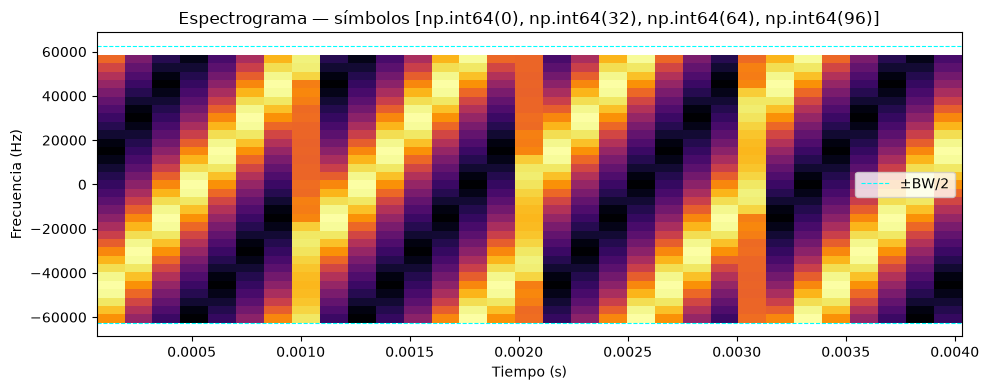

In [21]:
simbolos_vis = np.array([0, 32, 64, 96])
señal_vis = waveform_former(simbolos_vis, SF, BW, Fs).flatten()

fig, ax = plt.subplots(figsize=(10, 4))
ax.specgram(señal_vis, NFFT=N//4, Fs=Fs, noverlap=N//8,
            cmap='inferno', sides='twosided')
ax.set_title(f"Espectrograma — símbolos {list(simbolos_vis)}")
ax.set_xlabel("Tiempo (s)")
ax.set_ylabel("Frecuencia (Hz)")
ax.set_ylim(-BW/2 * 1.1, BW/2 * 1.1)
ax.axhline(-BW/2, color='cyan', linestyle='--', linewidth=0.8, label='±BW/2')
ax.axhline( BW/2, color='cyan', linestyle='--', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

## 11. Visualización 3: FFT después del dechirping

Esta gráfica muestra el mecanismo central del receptor: después del dechirping,
toda la energía del chirp se concentra en un único bin cuyo índice es el símbolo.


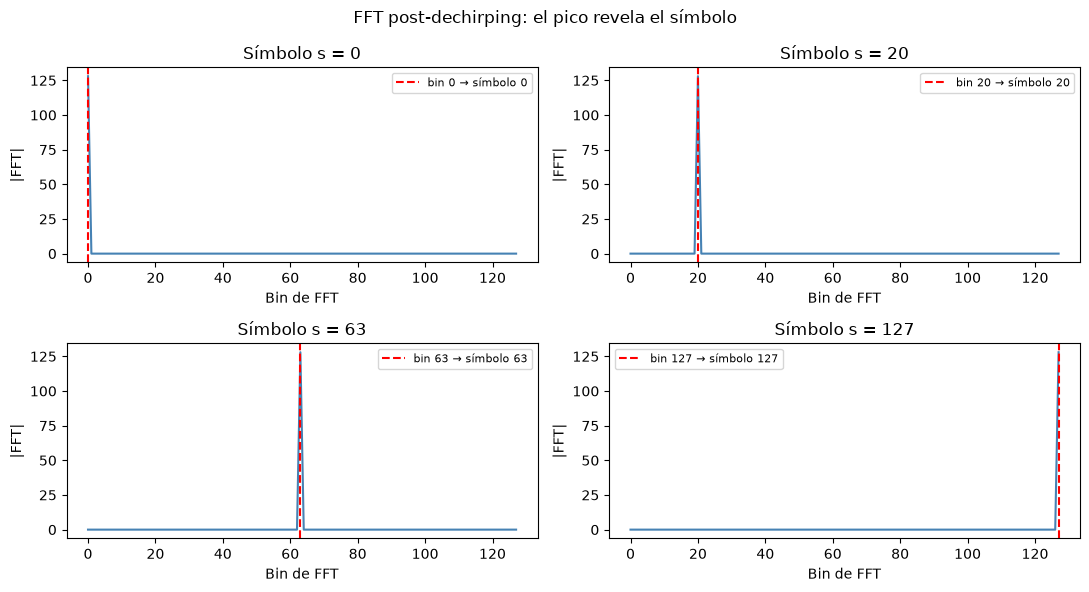

In [22]:
fig, axs = plt.subplots(2, 2, figsize=(11, 6))
simbolos_demo = [0, 20, 63, 127]

for ax, s in zip(axs.flatten(), simbolos_demo):
    wf_s = waveform_former([s], SF, BW, Fs)
    dechirped = wf_s[0] * down_chirp(SF, BW, Fs)
    espectro = np.abs(np.fft.fft(dechirped))

    ax.plot(espectro, color='steelblue')
    ax.axvline(s, color='red', linestyle='--', label=f'bin {s} → símbolo {s}')
    ax.set_title(f"Símbolo s = {s}")
    ax.set_xlabel("Bin de FFT")
    ax.set_ylabel("|FFT|")
    ax.legend(fontsize=8)

plt.suptitle("FFT post-dechirping: el pico revela el símbolo", fontsize=12)
plt.tight_layout()
plt.show()